In [410]:
import sys

sys.path.append("..")

import matplotlib.pyplot as plt
import numpy as np

In [411]:
from candidate.candidate import Candidate
from voter.voter import Voter
from election.election import Election
from election.result import ElectionResult
from analysis.analyzer import ResultsAnalyzer

from strategy.strategy import VotingStrategy
from strategy.plurality import PluralityStrategy
from strategy.borda import BordaCountStrategy
from strategy.veto import VetoStrategy

from visualization.util import (
    plot,
    plot_results,
    random_2d_points,
    random_2d_point,
    plot_winner_distance_histogram,
)

In [412]:
from pulp import *

In [413]:
def find_farthest_pair(points):
    max_dist_sq = -1
    best = (0, 1)
    for i in range(len(points)):
        for j in range(i + 1, len(points)):
            dx = points[i][0] - points[j][0]
            dy = points[i][1] - points[j][1]
            dist_sq = dx*dx + dy*dy
            if dist_sq > max_dist_sq:
                max_dist_sq = dist_sq
                best = (i, j)
    return best

def find_farthest_triple(points):
    max_dist_sum = -1
    best = (0, 1, 2)
    for i in range(len(points)):
        for j in range(i + 1, len(points)):
            for k in range(j + 1, len(points)):
                dx_ij = points[i][0] - points[j][0]
                dy_ij = points[i][1] - points[j][1]
                dx_ik = points[i][0] - points[k][0]
                dy_ik = points[i][1] - points[k][1]
                dx_jk = points[j][0] - points[k][0]
                dy_jk = points[j][1] - points[k][1]
                dist_sum = (dx_ij**2 + dy_ij**2)**0.5 + \
                           (dx_ik**2 + dy_ik**2)**0.5 + \
                           (dx_jk**2 + dy_jk**2)**0.5
                if dist_sum > max_dist_sum:
                    max_dist_sum = dist_sum
                    best = (i, j, k)
    return best

In [414]:
N_VOTERS = 100
N_CANDIDATES = 5

In [415]:
model = LpProblem("test", LpMinimize)

variables = [
    [
        LpVariable(f'{i}_{r}', lowBound=0, upBound=None, cat="Integer")
        for r in range(N_CANDIDATES)
    ]
    for i in range(N_CANDIDATES)
]

In [416]:
candidates = [Candidate(id=id, position=random_2d_point()) for id in range(N_CANDIDATES)]
idxs = find_farthest_triple([candidate.position for candidate in candidates])
WINNER_ONE_IDX=idxs[0]
WINNER_TWO_IDX=idxs[1]
WINNER_THREE_IDX=idxs[2]

In [417]:
for r in range(N_CANDIDATES):
    z = lpSum(
        variables[i][r]
        for i in range(N_CANDIDATES)
    )
    model += z == N_VOTERS

for i in range(N_CANDIDATES):
    z = lpSum(
        variables[i][r]
        for r in range(N_CANDIDATES)
    )
    model += z == N_VOTERS

# Plurality
for i in range(N_CANDIDATES):
    if i == WINNER_ONE_IDX: continue
    model += variables[WINNER_ONE_IDX][0] >= variables[i][0] + 1

# Borda
for i in range(N_CANDIDATES):
    if i == WINNER_TWO_IDX: continue
    sum1 = lpSum(
        (N_CANDIDATES - 1 - r) * variables[WINNER_TWO_IDX][r]
        for r in range(N_CANDIDATES - 1)
    )
    sum2 = lpSum(
        (N_CANDIDATES - 1 - r) * variables[i][r]
        for r in range(N_CANDIDATES - 1)
    )
    model += sum1 >= sum2 + 1

# Veto
for i in range(N_CANDIDATES):
    if i == WINNER_THREE_IDX: continue
    sum1 = lpSum(
        variables[WINNER_THREE_IDX][r]
        for r in range(N_CANDIDATES - 1)
    )
    sum2 = lpSum(
        variables[i][r]
        for r in range(N_CANDIDATES - 1)
    )
    model += sum1 >= sum2 + 1

In [418]:
solver = PULP_CBC_CMD(msg=True)
model.solve(solver)

1

In [419]:
print(LpStatus[model.status])

Optimal


In [420]:
for i in range(N_CANDIDATES):
    for j in range(N_CANDIDATES):
        print(f"variables[{i}][{j}] =", variables[i][j].varValue)

variables[0][0] = 50.0
variables[0][1] = 0.0
variables[0][2] = 47.0
variables[0][3] = 0.0
variables[0][4] = 3.0
variables[1][0] = 49.0
variables[1][1] = 2.0
variables[1][2] = 48.0
variables[1][3] = 0.0
variables[1][4] = 1.0
variables[2][0] = 0.0
variables[2][1] = 98.0
variables[2][2] = 0.0
variables[2][3] = 0.0
variables[2][4] = 2.0
variables[3][0] = 0.0
variables[3][1] = 0.0
variables[3][2] = 0.0
variables[3][3] = 100.0
variables[3][4] = 0.0
variables[4][0] = 1.0
variables[4][1] = 0.0
variables[4][2] = 5.0
variables[4][3] = 0.0
variables[4][4] = 94.0


In [421]:
# strategies = [PluralityStrategy(), BordaCountStrategy(), VetoStrategy()]
# election_results: list[ElectionResult] = []

# # candidates = [Candidate(id=id, position=random_2d_point()) for id in range(10)]

# N = 1000
# for _ in range(N):
#     candidates = [Candidate(id=id, position=random_2d_point()) for id in range(50)]
#     voters = [Voter(position=random_2d_point()) for _ in range(100)]
#     # voters = [Voter(position=cluster_point([(-2, 2), (2, 2)])) for _ in range(100)]
#     # voters = [Voter(position=cluster_point([(-2, -2), (2, -2), (-2, 2), (2, 2)])) for _ in range(100)]
#     election = Election(candidates=candidates, voters=voters)

#     election_result = election.compare_strategies(strategies=strategies)
#     election_results.append(election_result)

In [422]:
candidate_positions = np.array([c.position for c in candidates])
rng = np.random.default_rng()


def rank_of(point, cand_positions, i):
    """Return the rank of candidate i in the distance ordering from `point` (0 = closest)."""
    distances = np.linalg.norm(cand_positions - point, axis=1)
    return int(np.where(np.argsort(distances) == i)[0][0])


def sample_in_cell(i, r, cand_positions, bounds=(-5, 5), max_tries=200_000):
    """Rejection-sample a 2D point where candidate i sits at rank r."""
    for _ in range(max_tries):
        p = rng.uniform(bounds[0], bounds[1], size=2)
        if rank_of(p, cand_positions, i) == r:
            return p
    raise RuntimeError(f"could not sample for cell (i={i}, r={r}) — region may be empty in bounds")


voters_by_cell: dict[tuple[int, int], list[np.ndarray]] = {}
for i in range(N_CANDIDATES):
    for r in range(N_CANDIDATES):
        count = int(variables[i][r].varValue or 0)
        voters_by_cell[(i, r)] = [
            sample_in_cell(i, r, candidate_positions) for _ in range(count)
        ]

total = sum(len(v) for v in voters_by_cell.values())
print(f"Generated {total} voters across {sum(1 for v in voters_by_cell.values() if v)} non-empty cells")

Generated 500 voters across 13 non-empty cells


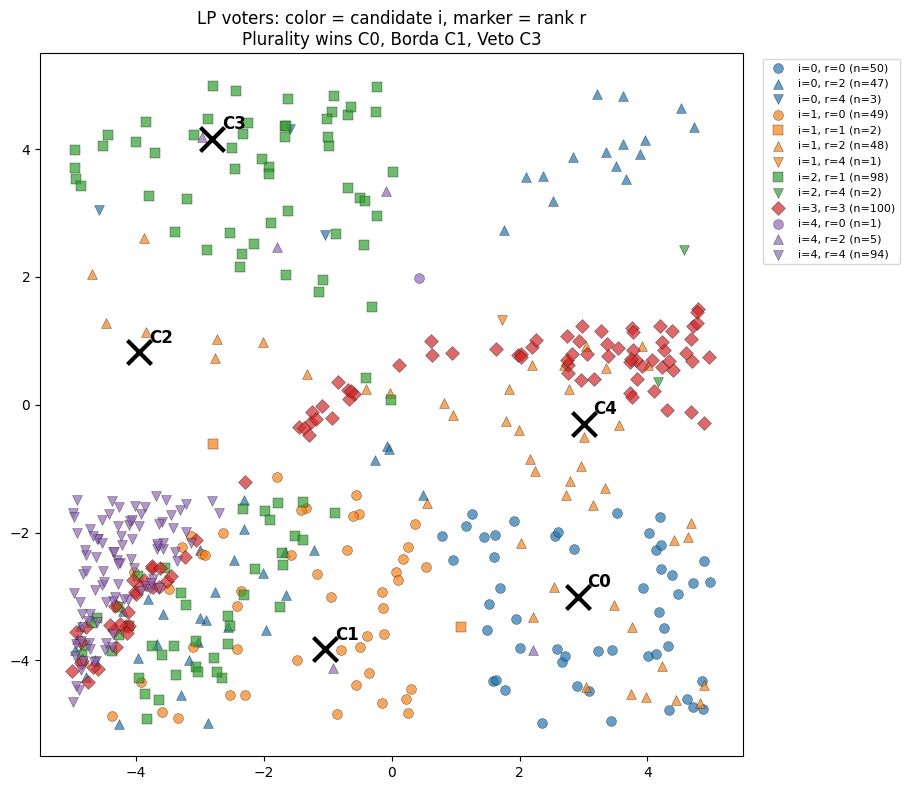

In [423]:
fig, ax = plt.subplots(figsize=(9, 8))
colors = plt.cm.tab10.colors
markers = ["o", "s", "^", "D", "v", "P", "*"]

for (i, r), pts in voters_by_cell.items():
    if not pts:
        continue
    arr = np.array(pts)
    ax.scatter(
        arr[:, 0], arr[:, 1],
        color=colors[i % len(colors)],
        marker=markers[r % len(markers)],
        s=50,
        alpha=0.7,
        edgecolors="black",
        linewidths=0.3,
        label=f"i={i}, r={r} (n={len(pts)})",
    )

for idx, c in enumerate(candidates):
    ax.scatter(*c.position, marker="x", s=300, c="black", linewidths=3)
    ax.annotate(
        f"C{idx}", c.position,
        fontsize=12, fontweight="bold",
        xytext=(7, 7), textcoords="offset points",
    )

ax.set_aspect("equal")
ax.set_xlim(-5.5, 5.5)
ax.set_ylim(-5.5, 5.5)
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1), fontsize=8)
ax.set_title(
    f"LP voters: color = candidate i, marker = rank r\n"
    f"Plurality wins C{WINNER_ONE_IDX}, Borda C{WINNER_TWO_IDX}, Veto C{WINNER_THREE_IDX}"
)
plt.tight_layout()
plt.show()